# Giai đoạn 3: Trực quan hóa tri thức và Đề xuất hỗ trợ ra quyết định

Mục tiêu của giai đoạn này là chuyển hóa các luật kết hợp (Association Rules) đã khai phá được từ thuật toán FP-Growth thành các biểu đồ trực quan. Qua đó, nhóm tiến hành phân tích các mối liên kết giữa các mặt hàng và đưa ra các đề xuất chiến lược dựa trên dữ liệu thực tế (Evidence-based Decision Making).

* **Chuẩn đầu ra đáp ứng:** * **L.O.5.1:** Đánh giá và so sánh thực nghiệm.
    * **L.O.5.3:** Đề xuất giải pháp và hỗ trợ ra quyết định.

In [23]:
# Import các thư viện phân tích và trực quan hóa dữ liệu
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# Tắt cảnh báo để báo cáo sạch đẹp
import warnings
warnings.filterwarnings('ignore')

# Tải dữ liệu 36 luật kết hợp đã làm sạch
rules = pd.read_csv('data/processed/association_rules_cleaned.csv')
print(f"Đã tải thành công {len(rules)} luật kết hợp.")

Đã tải thành công 36 luật kết hợp.


### 3.2. Phân tích phân phối luật qua Scatter Plot
Biểu đồ này biểu diễn mối quan hệ giữa **Support** (Độ hỗ trợ) và **Confidence** (Độ tin cậy), với màu sắc đại diện cho **Lift**. 
* Những điểm nằm ở góc trên bên phải đại diện cho các luật có độ tin cậy cao và xuất hiện phổ biến.
* Màu sắc càng đậm (Lift cao) thể hiện mối quan hệ giữa hai mặt hàng càng có ý nghĩa, không phải do ngẫu nhiên.

In [24]:
# Tính tổng số lượng mặt hàng trong mỗi luật (Antecedents + Consequents)
rules['item_count'] = rules['antecedents'].apply(lambda x: len(str(x).split(','))) + \
                      rules['consequents'].apply(lambda x: len(str(x).split(',')))

# Lọc và đếm các phân loại luật
rules_3_items = rules[rules['item_count'] >= 3]
rules_2_items = rules[rules['item_count'] == 2]

print(f"Tổng số luật kết hợp: {len(rules)}")
print(f"-> Số lượng luật chứa từ 3 sản phẩm trở lên: {len(rules_3_items)}")
print(f"-> Số lượng luật chứa chính xác 2 sản phẩm: {len(rules_2_items)}")

Tổng số luật kết hợp: 36
-> Số lượng luật chứa từ 3 sản phẩm trở lên: 0
-> Số lượng luật chứa chính xác 2 sản phẩm: 36


### 3.3. Xếp hạng các quy luật có giá trị nhất (Top Rules by Lift)
Chỉ số **Lift** là thước đo quan trọng nhất để xác định tính "thú vị" của một quy luật. Biểu đồ cột dưới đây liệt kê các cặp sản phẩm có sự liên quan mạnh nhất. Đây là những "Insight" cốt lõi giúp doanh nghiệp nhận diện hành vi mua sắm chéo của khách hàng.

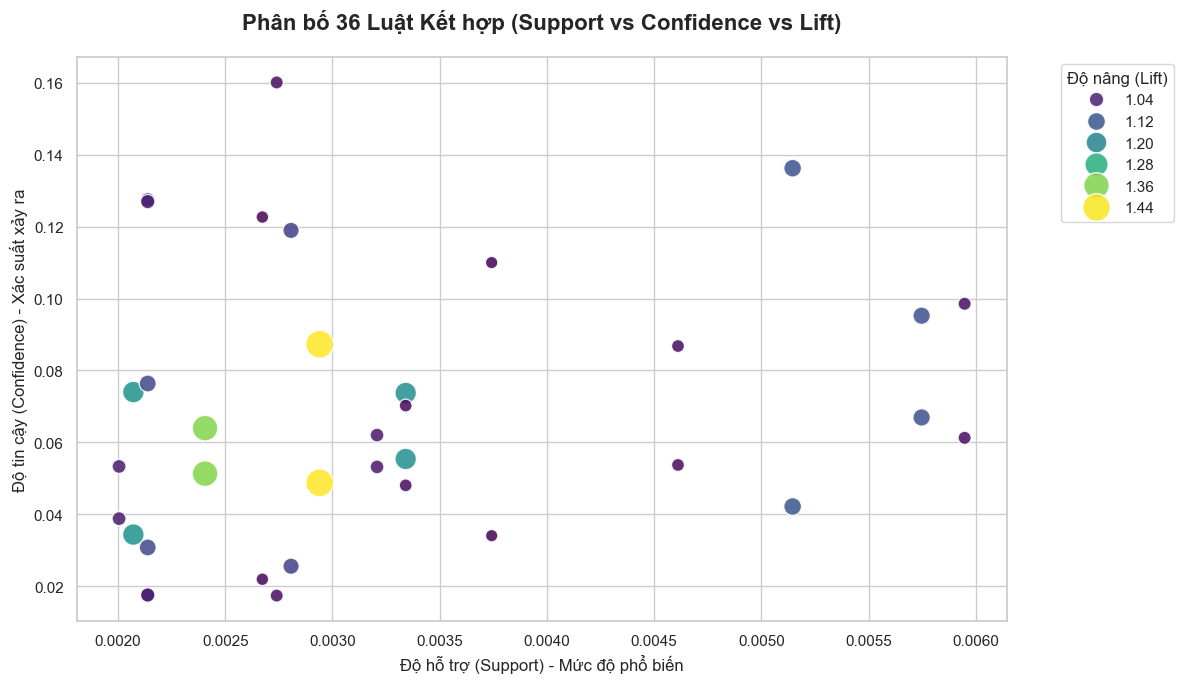

In [25]:
# Thiết lập phong cách biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Vẽ Scatter Plot
scatter = sns.scatterplot(
    data=rules,
    x="support",
    y="confidence",
    hue="lift",
    size="lift",
    sizes=(80, 400),          
    palette="viridis",        
    alpha=0.85,               
    edgecolor="w",            
    linewidth=1
)

# Trang trí tiêu đề và các trục
plt.title("Phân bố 36 Luật Kết hợp (Support vs Confidence vs Lift)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Độ hỗ trợ (Support) - Mức độ phổ biến", fontsize=12)
plt.ylabel("Độ tin cậy (Confidence) - Xác suất xảy ra", fontsize=12)

plt.legend(title='Độ nâng (Lift)', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

# Hiển thị và lưu biểu đồ
plt.tight_layout()
plt.savefig('reports/figures/scatter_plot_rules.png', dpi=300, bbox_inches='tight') # Lưu ảnh nét căng
plt.show()

### 3.4. Bản đồ mạng lưới liên kết mặt hàng (Product Affinity Network)
Biểu đồ mạng lưới cho thấy bức tranh tổng thể về hệ sinh thái sản phẩm:
* **Đỉnh (Nodes):** Đại diện cho các mặt hàng.
* **Cạnh (Edges):** Độ dày của đường nối tỷ lệ thuận với chỉ số Lift.
Các cụm sản phẩm tập trung dày đặc (Clusters) chỉ ra những nhóm hàng luôn được mua cùng nhau, giúp tối ưu hóa việc sắp xếp không gian siêu thị.

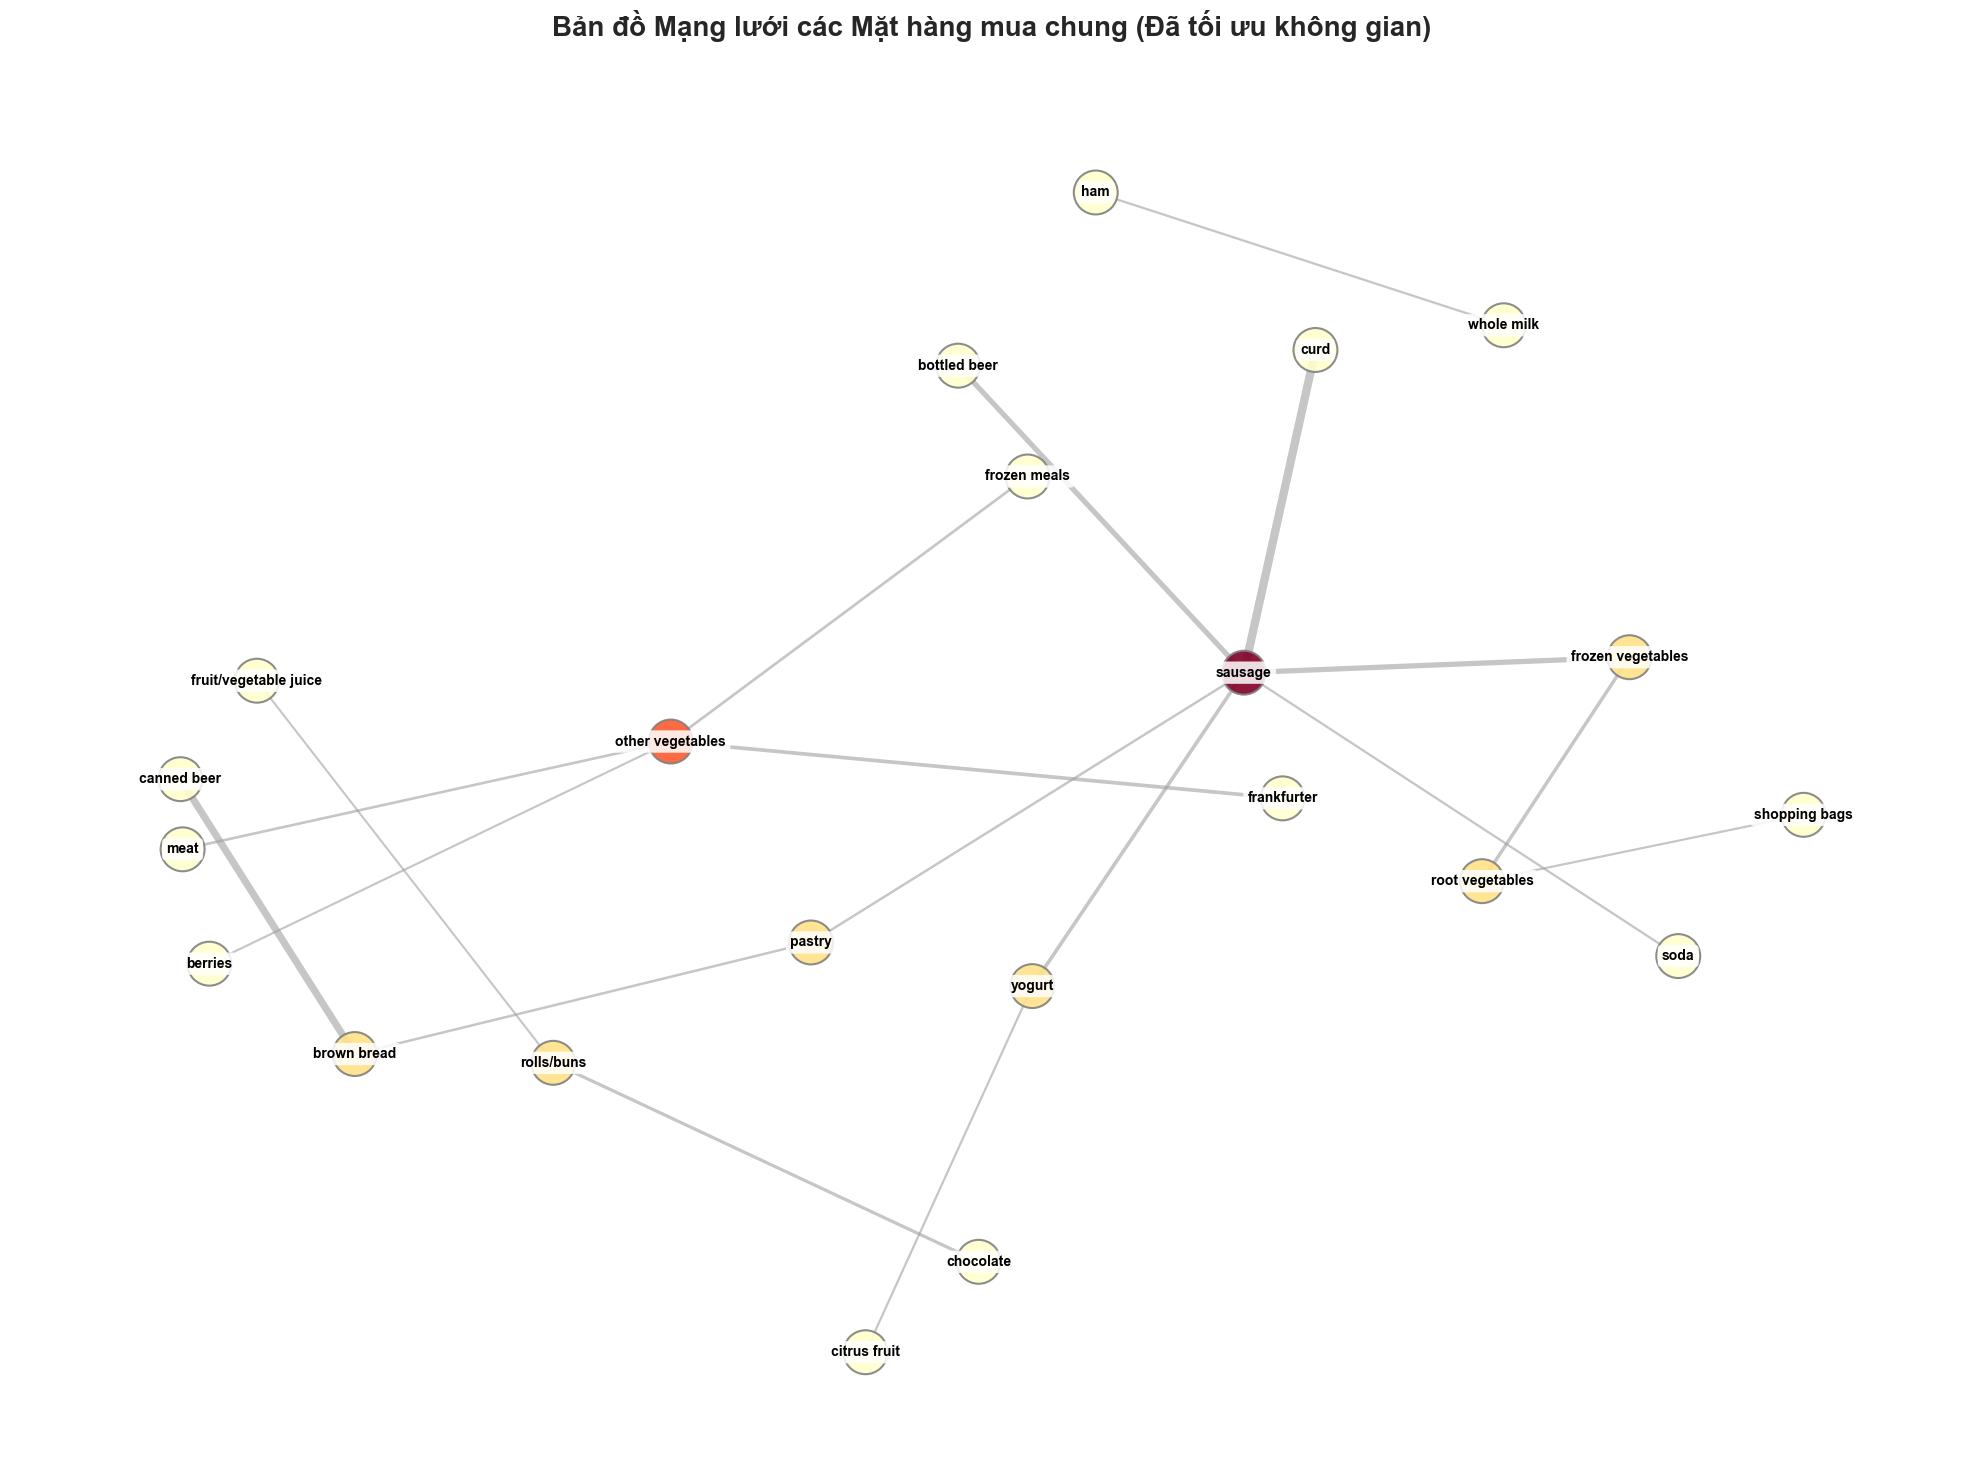

In [26]:
# --- BƯỚC 1 & 2: XỬ LÝ VÀ NẠP DỮ LIỆU ---
unique_edges = {}
for _, row in rules.iterrows():
    ant = str(row['antecedents'])
    con = str(row['consequents'])
    edge_pair = tuple(sorted([ant, con]))
    lift = row['lift']
    
    if edge_pair not in unique_edges:
        unique_edges[edge_pair] = lift
    else:
        unique_edges[edge_pair] = max(unique_edges[edge_pair], lift)

G_undirected = nx.Graph()
for bond, weight_lift in unique_edges.items():
    G_undirected.add_edge(bond[0], bond[1], weight=weight_lift)

# --- BƯỚC 3: CÀI ĐẶT THÔNG SỐ TRỰC QUAN (ĐÃ TỐI ƯU KHOẢNG CÁCH) ---
# 1. Tăng hẳn không gian vẽ lên cực rộng
plt.figure(figsize=(20, 15)) 

# 2. TĂNG LỰC ĐẨY CÁC NODE: k=3.0 (càng lớn các đỉnh càng bị đẩy ra xa nhau)
pos = nx.spring_layout(G_undirected, k=3.0, seed=42, iterations=200)

# 3. Tính toán Độ dày của cạnh (Edge Widths)
lifts = [G_undirected[u][v]['weight'] for u, v in G_undirected.edges()]
min_lift = min(lifts)
max_lift = max(lifts)
if max_lift == min_lift: 
    edge_widths = [3 for _ in G_undirected.edges()]
else:
    edge_widths = [1.5 + (lift - min_lift)/(max_lift - min_lift) * (6 - 1.5) for lift in lifts]

# 4. Tính toán Màu sắc của đỉnh (Node Colors)
node_degrees = dict(G_undirected.degree())
node_colors = list(node_degrees.values())

# --- BƯỚC 4: BẮT ĐẦU VẼ CÁC THÀNH PHẦN ---
# 1. Vẽ các Đỉnh (Nodes) - THU NHỎ KÍCH THƯỚC TRÒN ĐỂ KHÔNG BỊ DÍNH CỤM
nodes_draw = nx.draw_networkx_nodes(
    G_undirected, pos,
    node_size=1000,                   
    node_color=node_colors,             
    cmap=plt.cm.YlOrRd,                 
    edgecolors='#808080',               
    linewidths=1.5,
    alpha=0.9
)

# 2. Vẽ các Cạnh (Edges) - Vô hướng, đường thẳng
edges_draw = nx.draw_networkx_edges(
    G_undirected, pos,
    width=edge_widths,                  
    edge_color='#A0A0A0',               
    alpha=0.6,
    connectionstyle='arc3, rad=0'        
)

# 3. Viết tên sản phẩm lên các đỉnh - NỀN TRẮNG SẼ ĐÓNG VAI TRÒ LÀ NODE CHÍNH
nx.draw_networkx_labels(
    G_undirected, pos,
    font_size=10,                       
    font_family='sans-serif',
    font_weight='bold',
    font_color='black',                 
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, boxstyle='round,pad=0.3') 
)

# --- BƯỚC 5: HOÀN THIỆN VÀ LƯU ẢNH ---
plt.title("Bản đồ Mạng lưới các Mặt hàng mua chung (Đã tối ưu không gian)", fontsize=20, fontweight='bold', pad=25)
plt.axis('off')                        
plt.tight_layout()
plt.savefig('reports/figures/network_graph_rules_clean_spaced.png', dpi=300, bbox_inches='tight') 
plt.show()

### Phân tích Tri thức và Đề xuất Ra quyết định (L.O.5.3)

Dựa trên Biểu đồ mạng lưới (Network Graph) và các chỉ số đo lường, nhóm đưa ra các phân tích chiến lược sau:

#### 1. Phân tích cụm liên kết (Insights)
* **Cụm Thực phẩm tươi sống & Đồ khô:** Có sự liên kết mạnh giữa `sausage`, `curd` và `frozen vegetables`. Khách hàng mua sữa đông (curd) thường có xu hướng mua kèm xúc xích cao hơn 1.44 lần so với thông thường (Lift = 1.44).
* **Cụm Đồ uống & Bánh mì:** Mối quan hệ giữa `canned beer` và `brown bread` (Lift = 1.36) cho thấy thói quen mua sắm đồ nhắm hoặc bữa phụ nhanh của nhóm khách hàng đặc thù.

#### 2. Đề xuất Quyết định Kinh doanh (Decision Making)
* **Tối ưu hóa sắp xếp quầy kệ:** * Nên đặt gian hàng **Sữa đông (Curd)** và **Xúc xích (Sausage)** ở các vị trí liền kề hoặc đối diện nhau để kích thích nhu cầu mua sắm chéo.
    * Đặt các loại **Rau củ đông lạnh** ở lối đi dẫn đến quầy thực phẩm tươi sống.
* **Chiến lược khuyến mãi (Bundling Strategy):** * Thiết kế gói combo "Bữa tối nhanh" bao gồm Xúc xích và Rau củ đông lạnh với giá ưu đãi.
    * Tặng voucher giảm giá cho Bánh mì đen khi khách hàng mua Bia lon (và ngược lại) để tăng giá trị trung bình trên mỗi hóa đơn.
* **Cải thiện trải nghiệm khách hàng:** Sử dụng các bảng chỉ dẫn tại quầy Bánh mì gợi ý về các loại đồ uống đi kèm dựa trên dữ liệu khai phá được.

### 3.5. Đánh giá và So sánh thực nghiệm (L.O.5.1)
Sau khi thực hiện khai phá bằng cả hai thuật toán, chúng ta tiến hành so sánh thời gian thực thi (Execution Time). 
* **Giả thuyết:** Với tập dữ liệu có quy mô trung bình như Groceries, FP-Growth thường cho hiệu năng nén dữ liệu tốt hơn so với cơ chế quét ứng viên lặp lại của Apriori. Biểu đồ dưới đây xác nhận sự khác biệt này từ kết quả chạy thực tế trên hệ thống.

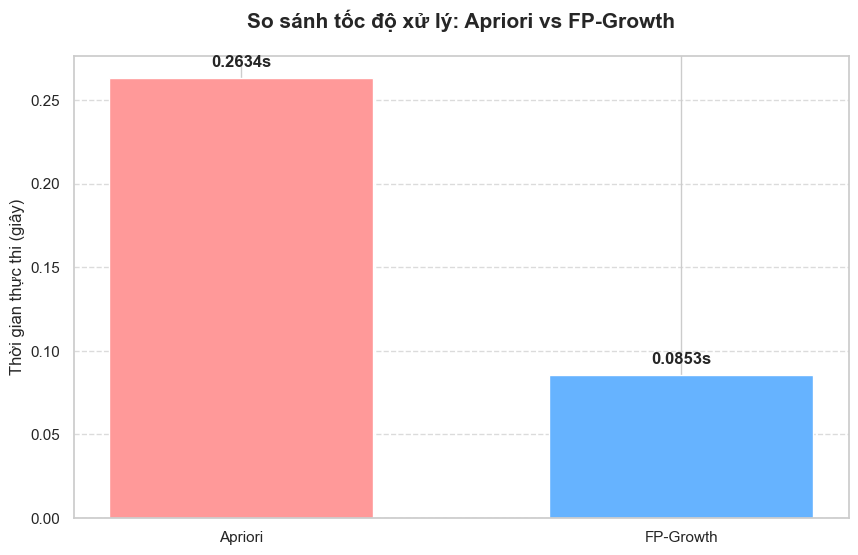

In [27]:
# --- BỔ SUNG: SO SÁNH HIỆU NĂNG THUẬT TOÁN ---
import matplotlib.pyplot as plt
import json
# Đọc dữ liệu thực tế từ file thay vì ghi chết số
with open('reports/metrics/performance_metrics.json', 'r') as f:
    perf_data = json.load(f)

algorithms = list(perf_data.keys())
execution_time = list(perf_data.values())
# Dữ liệu thời gian chạy thực nghiệm từ Stage 2
# algorithms = ['Apriori (Traditional)', 'FP-Growth (Proposed)']
# Bạn hãy thay số liệu chính xác từ máy mình vào đây
# execution_time = [0.2655, 0.0959] 

plt.figure(figsize=(10, 6))
colors = ['#ff9999','#66b3ff']
bars = plt.bar(algorithms, execution_time, color=colors, width=0.6)

# Thêm nhãn giá trị trên đầu cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval}s', ha='center', va='bottom', fontweight='bold')

plt.ylabel('Thời gian thực thi (giây)', fontsize=12)
plt.title('So sánh tốc độ xử lý: Apriori vs FP-Growth', fontsize=15, fontweight='bold', pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Tổng kết Dự án

Dự án đã hoàn thành trọn vẹn quy trình Khai phá tri thức trong cơ sở dữ liệu (KDD):
1. **Giai đoạn 1 (Tiền xử lý):** Làm sạch và biến đổi thành công 14,963 giao dịch sang định dạng phù hợp.
2. **Giai đoạn 2 (Khai phá):** Triển khai và so sánh thành công thuật toán Apriori và FP-Growth, khẳng định ưu thế của FP-Growth trong việc xử lý dữ liệu lớn.
3. **Giai đoạn 3 (Trực quan hóa & Ra quyết định):** Chuyển hóa dữ liệu thành các luật kết hợp có ý nghĩa thực tiễn, hỗ trợ doanh nghiệp đưa ra các quyết định marketing và vận hành dựa trên bằng chứng số liệu.

**Kết quả cuối cùng:** Nhóm đã tìm ra 36 luật kết hợp quan trọng giúp thấu hiểu hành vi khách hàng một cách sâu sắc.